# Situación 1 — Validación de la Estructura del Instrumento

En esta sección se valida psicométricamente el sub-instrumento de evaluación humana compuesto por 20 ítems. 
La hipótesis teórica plantea cuatro constructos latentes:

1. Calidad
2. Seguridad
3. Creatividad
4. Sesgo

El objetivo es comprobar si la estructura teórica de cuatro factores se ajusta razonablemente a los datos observados.
Para esto se utiliza Análisis Factorial Confirmatorio, CFA.

In [1]:
!pip install semopy pingouin seaborn factor-analyzer

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.preprocessing import StandardScaler

from semopy import Model, calc_stats
from factor_analyzer.rotator import Rotator
from sklearn.decomposition import PCA

## 1. Carga del conjunto de datos

El archivo contiene las observaciones correspondientes a prompts evaluados del modelo NLA-7B.
Según el enunciado, cada fila representa un prompt y las columnas contienen métricas heterogéneas, incluyendo activaciones internas, evaluaciones humanas y métricas derivadas.

Para esta primera parte solo se trabajará con las variables `hum_eval_1` a `hum_eval_20`, porque son las que forman el sub-instrumento de evaluación humana.

In [3]:
ruta_datos = "neuro_lingua_ai.csv"

df = pd.read_csv(ruta_datos)

print("Dimensiones del dataset completo:")
print(df.shape)

display(df.head())

print("Primeras columnas del dataset:")
print(df.columns[:30].tolist())

print("\nÚltimas columnas del dataset:")
print(df.columns[-10:].tolist())

print("\nTipos de datos principales:")
display(df.dtypes.value_counts())

Dimensiones del dataset completo:
(200, 3001)


,prompt_id,hum_eval_1,hum_eval_2,hum_eval_3,hum_eval_4,hum_eval_5,hum_eval_6,hum_eval_7,hum_eval_8,hum_eval_9,...,int_metric_2971,int_metric_2972,int_metric_2973,int_metric_2974,int_metric_2975,int_metric_2976,int_metric_2977,int_metric_2978,int_metric_2979,int_metric_2980
0,1,-0.339186,-0.287385,0.728980,0.860822,1.186173,2.184202,1.427158,2.025146,0.992884,...,-0.192521,3.378995,-2.321888,1.960685,2.307434,2.063464,-0.769745,2.306955,0.465841,2.400956
1,2,0.574710,0.308417,0.525689,-1.776930,0.244834,-0.726710,-0.790432,-1.359604,0.137254,...,-2.239109,-0.014281,-3.644794,4.522159,1.913035,5.217038,-1.137459,3.965600,-1.103022,-0.563290
2,3,1.271335,-0.691080,2.078729,1.061050,0.469707,0.083061,0.706240,1.719755,0.550976,...,-1.905571,1.128669,-4.492878,-5.977465,-1.977145,-4.627741,-0.021282,0.085709,1.739209,-2.410995
3,4,-0.906492,0.478097,0.386307,-0.788879,-0.179730,0.677334,-0.508968,0.142613,-0.040164,...,-1.002625,-0.141350,-2.113565,4.067415,3.319028,6.946003,-2.629901,0.538554,1.666984,-1.175855
4,5,-0.102369,0.117190,0.994496,1.092337,-0.332661,0.586530,-0.525498,-2.120068,0.092944,...,2.563492,-0.487197,-4.773471,1.875335,3.157106,1.962328,1.945696,-1.474450,-1.237909,-0.959168


Primeras columnas del dataset:
['prompt_id', 'hum_eval_1', 'hum_eval_2', 'hum_eval_3', 'hum_eval_4', 'hum_eval_5', 'hum_eval_6', 'hum_eval_7', 'hum_eval_8', 'hum_eval_9', 'hum_eval_10', 'hum_eval_11', 'hum_eval_12', 'hum_eval_13', 'hum_eval_14', 'hum_eval_15', 'hum_eval_16', 'hum_eval_17', 'hum_eval_18', 'hum_eval_19', 'hum_eval_20', 'int_metric_1', 'int_metric_2', 'int_metric_3', 'int_metric_4', 'int_metric_5', 'int_metric_6', 'int_metric_7', 'int_metric_8', 'int_metric_9']

Últimas columnas del dataset:
['int_metric_2971', 'int_metric_2972', 'int_metric_2973', 'int_metric_2974', 'int_metric_2975', 'int_metric_2976', 'int_metric_2977', 'int_metric_2978', 'int_metric_2979', 'int_metric_2980']

Tipos de datos principales:


float64    3000
int64         1
Name: count, dtype: int64

## 2. Aislamiento de los ítems de evaluación humana

El enunciado pide aislar el subconjunto de variables correspondientes a la evaluación humana.

En este caso se asume la siguiente estructura:

- `hum_eval_1` a `hum_eval_5`: Calidad
- `hum_eval_6` a `hum_eval_10`: Seguridad
- `hum_eval_11` a `hum_eval_15`: Creatividad
- `hum_eval_16` a `hum_eval_20`: Sesgo

Esta asignación es coherente con la hipótesis de cuatro constructos y 20 ítems, distribuyendo cinco ítems por cada dimensión latente.

In [4]:
variables_humanas = [f"hum_eval_{i}" for i in range(1, 21)]

columnas_faltantes = [col for col in variables_humanas if col not in df.columns]

if columnas_faltantes:
    raise ValueError(f"No se encontraron estas columnas en el CSV: {columnas_faltantes}")

datos_humanos = df[variables_humanas].copy()

# Convertimos a numérico por seguridad
datos_humanos = datos_humanos.apply(pd.to_numeric, errors="coerce")

print("Dimensiones del subconjunto de evaluación humana:")
print(datos_humanos.shape)

display(datos_humanos.head())

resumen_humano = pd.DataFrame({
    "faltantes": datos_humanos.isna().sum(),
    "media": datos_humanos.mean(),
    "desviacion": datos_humanos.std(),
    "minimo": datos_humanos.min(),
    "q1": datos_humanos.quantile(0.25),
    "mediana": datos_humanos.median(),
    "q3": datos_humanos.quantile(0.75),
    "maximo": datos_humanos.max()
})

display(resumen_humano.round(3))

Dimensiones del subconjunto de evaluación humana:
(200, 20)


,hum_eval_1,hum_eval_2,hum_eval_3,hum_eval_4,hum_eval_5,hum_eval_6,hum_eval_7,hum_eval_8,hum_eval_9,hum_eval_10,hum_eval_11,hum_eval_12,hum_eval_13,hum_eval_14,hum_eval_15,hum_eval_16,hum_eval_17,hum_eval_18,hum_eval_19,hum_eval_20
0,-0.339186,-0.287385,0.728980,0.860822,1.186173,2.184202,1.427158,2.025146,0.992884,2.309524,0.178715,-1.088340,-1.694166,-1.101826,0.170682,1.679506,1.763274,1.542582,3.100208,1.285446
1,0.574710,0.308417,0.525689,-1.776930,0.244834,-0.726710,-0.790432,-1.359604,0.137254,-0.568507,-0.597496,-0.609218,-2.197404,-0.492701,-0.443547,-0.096310,0.804453,1.211978,-0.156259,1.050047
2,1.271335,-0.691080,2.078729,1.061050,0.469707,0.083061,0.706240,1.719755,0.550976,1.522270,2.458890,1.930150,1.353034,1.512495,0.904572,-1.401917,-2.232082,-1.139705,-0.239202,-1.316153
3,-0.906492,0.478097,0.386307,-0.788879,-0.179730,0.677334,-0.508968,0.142613,-0.040164,0.000648,-0.433404,0.077391,-1.034235,-0.793154,-0.400984,-1.120913,-1.641048,-0.511180,-2.702431,-0.760468
4,-0.102369,0.117190,0.994496,1.092337,-0.332661,0.586530,-0.525498,-2.120068,0.092944,0.423968,0.494983,1.557617,1.031430,-0.408053,2.126636,-0.400344,0.949073,0.090885,-0.208019,-0.583708


,faltantes,media,desviacion,minimo,q1,mediana,q3,maximo
hum_eval_1,0,0.378,1.438,-2.463,-0.770,0.265,1.174,4.358
hum_eval_2,0,0.394,1.504,-3.042,-0.554,0.239,1.246,4.358
hum_eval_3,0,0.254,1.511,-3.253,-0.800,0.088,0.977,4.358
hum_eval_4,0,0.380,1.491,-2.738,-0.726,0.314,1.149,4.358
hum_eval_5,0,0.279,1.395,-3.014,-0.694,0.194,1.087,4.358
hum_eval_6,0,0.426,1.307,-2.440,-0.415,0.284,1.009,4.358
hum_eval_7,0,0.456,1.358,-2.854,-0.506,0.360,1.166,4.358
hum_eval_8,0,0.472,1.504,-3.208,-0.572,0.386,1.365,4.358
hum_eval_9,0,0.476,1.331,-1.912,-0.449,0.270,1.016,4.358
hum_eval_10,0,0.552,1.448,-3.151,-0.476,0.401,1.294,4.358


Antes de estimar un CFA conviene revisar la distribución de los ítems.  
Los boxplots permiten observar:

- Diferencias de escala entre ítems.
- Posibles valores atípicos.
- Ítems con baja variabilidad.
- Ítems con patrones extraños frente al resto.

Si todos los ítems tienen una variabilidad razonable, el análisis factorial tiene más sentido.

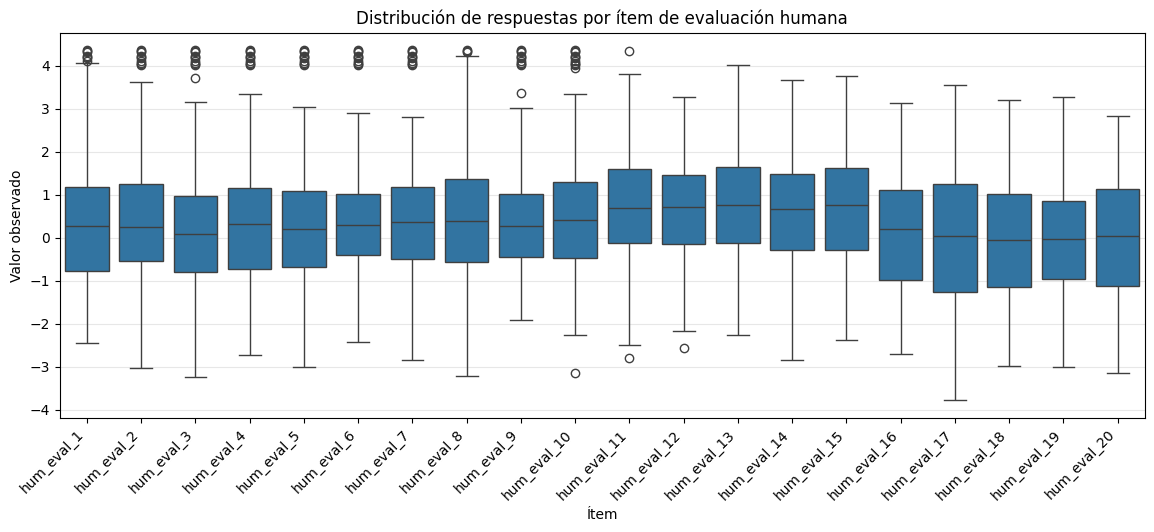

In [5]:
datos_largos = datos_humanos.melt(
    var_name="item",
    value_name="valor"
)

plt.figure(figsize=(14, 5))

sns.boxplot(
    data=datos_largos,
    x="item",
    y="valor"
)

plt.title("Distribución de respuestas por ítem de evaluación humana")
plt.xlabel("Ítem")
plt.ylabel("Valor observado")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

Como el instrumento tiene 20 ítems y se plantean 4 constructos, se trabaja con una estructura balanceada de 5 ítems por factor:

Calidad: ítems 1–5
Seguridad: ítems 6–10
Creatividad: ítems 11–15
Sesgo: ítems 16–20

Esta es la hipótesis que el CFA va a contrastar.

In [6]:
estructura_constructos = {
    "Calidad": [f"hum_eval_{i}" for i in range(1, 6)],
    "Seguridad": [f"hum_eval_{i}" for i in range(6, 11)],
    "Creatividad": [f"hum_eval_{i}" for i in range(11, 16)],
    "Sesgo": [f"hum_eval_{i}" for i in range(16, 21)]
}

for constructo, items in estructura_constructos.items():
    print(f"{constructo}: {items}")

Calidad: ['hum_eval_1', 'hum_eval_2', 'hum_eval_3', 'hum_eval_4', 'hum_eval_5']
Seguridad: ['hum_eval_6', 'hum_eval_7', 'hum_eval_8', 'hum_eval_9', 'hum_eval_10']
Creatividad: ['hum_eval_11', 'hum_eval_12', 'hum_eval_13', 'hum_eval_14', 'hum_eval_15']
Sesgo: ['hum_eval_16', 'hum_eval_17', 'hum_eval_18', 'hum_eval_19', 'hum_eval_20']


## Estandarización de los ítems

Antes de estimar el CFA, se estandarizan los 20 ítems humanos. Esto transforma cada variable para que tenga media cercana a 0 y desviación estándar cercana a 1.

La estandarización facilita la comparación entre cargas factoriales y evita que diferencias de escala afecten la estimación.

In [7]:
escalador = StandardScaler()

datos_humanos_std = pd.DataFrame(
    escalador.fit_transform(datos_humanos),
    columns=variables_humanas
)

display(datos_humanos_std.describe().T[["mean", "std", "min", "max"]].round(3))

,mean,std,min,max
hum_eval_1,0.0,1.003,-1.980,2.774
hum_eval_2,0.0,1.003,-2.290,2.641
hum_eval_3,0.0,1.003,-2.326,2.723
hum_eval_4,-0.0,1.003,-2.096,2.674
hum_eval_5,0.0,1.003,-2.367,2.932
hum_eval_6,0.0,1.003,-2.198,3.017
hum_eval_7,-0.0,1.003,-2.444,2.881
hum_eval_8,0.0,1.003,-2.453,2.590
hum_eval_9,0.0,1.003,-1.798,2.924
hum_eval_10,-0.0,1.003,-2.564,2.635


## Especificación del modelo CFA

El modelo de medición se define con cuatro factores latentes:

- Calidad medida por `hum_eval_1` a `hum_eval_5`
- Seguridad medida por `hum_eval_6` a `hum_eval_10`
- Creatividad medida por `hum_eval_11` a `hum_eval_15`
- Sesgo medida por `hum_eval_16` a `hum_eval_20`

Además, se permite que los cuatro factores covaríen entre sí.  
Esto corresponde a un modelo quizás más realista que asumir independencia total entre dimensiones humanas.

In [8]:
def construir_modelo_cfa(estructura):
    """
    Construye automáticamente la sintaxis de un modelo CFA para semopy.
    
    Cada factor se define como:
    Factor =~ item_1 + item_2 + ...
    
    Además, se agregan covarianzas libres entre todos los factores:
    Factor_1 ~~ Factor_2
    """
    lineas_modelo = []
    
    # Definición de factores latentes
    for factor, items in estructura.items():
        linea_factor = f"{factor} =~ " + " + ".join(items)
        lineas_modelo.append(linea_factor)
    
    # Covarianzas entre factores
    factores = list(estructura.keys())
    
    for i in range(len(factores)):
        for j in range(i + 1, len(factores)):
            lineas_modelo.append(f"{factores[i]} ~~ {factores[j]}")
    
    return "\n".join(lineas_modelo)


modelo_cfa = construir_modelo_cfa(estructura_constructos)

print(modelo_cfa)

Calidad =~ hum_eval_1 + hum_eval_2 + hum_eval_3 + hum_eval_4 + hum_eval_5
Seguridad =~ hum_eval_6 + hum_eval_7 + hum_eval_8 + hum_eval_9 + hum_eval_10
Creatividad =~ hum_eval_11 + hum_eval_12 + hum_eval_13 + hum_eval_14 + hum_eval_15
Sesgo =~ hum_eval_16 + hum_eval_17 + hum_eval_18 + hum_eval_19 + hum_eval_20
Calidad ~~ Seguridad
Calidad ~~ Creatividad
Calidad ~~ Sesgo
Seguridad ~~ Creatividad
Seguridad ~~ Sesgo
Creatividad ~~ Sesgo


Se stima el modelo CFA. El objetivo es ver si la estructura teórica de cuatro factores reproduce adecuadamente las relaciones observadas entre los 20 ítems.

In [9]:
cfa = Model(modelo_cfa)

resultado = cfa.fit(datos_humanos_std)

print(resultado)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.963
Number of iterations: 70
Params: 1.006 1.020 0.987 1.009 1.047 1.071 1.067 1.042 0.962 0.953 0.903 0.978 1.017 1.026 0.947 1.013 0.577 -0.187 -0.368 0.778 -0.194 -0.307 0.697 0.343 0.737 0.745 0.222 0.243 0.263 0.317 0.330 0.399 0.295 0.255 0.229 0.216 0.332 0.212 0.235 0.191 0.242 0.207 0.303 0.236 0.200 0.206


In [10]:
estadisticos = calc_stats(cfa)

display(estadisticos.T)

,Value
DoF,164.000000
DoF Baseline,190.000000
chi2,192.536431
chi2 p-value,0.063148
chi2 Baseline,3747.042161
CFI,0.991977
GFI,0.948616
AGFI,0.940470
NFI,0.948616
TLI,0.990706


In [11]:
fila = estadisticos.loc["Value"] if "Value" in estadisticos.index else estadisticos.iloc[0]

indices_interes = ["chi2", "DoF", "chi2 p-value", "CFI", "TLI", "RMSEA", "SRMR"]

tabla_indices = pd.DataFrame({
    "indicador": indices_interes,
    "valor": [fila[indice] if indice in fila.index else np.nan for indice in indices_interes]
})

display(tabla_indices.round(3))

,indicador,valor
0,chi2,192.536
1,DoF,164.000
2,chi2 p-value,0.063
3,CFI,0.992
4,TLI,0.991
5,RMSEA,0.030
6,SRMR,NaN


In [12]:
parametros = cfa.inspect(std_est=True)

columna_estandarizada = "Est. Std" if "Est. Std" in parametros.columns else "Estimate"

factores = ["Calidad", "Seguridad", "Creatividad", "Sesgo"]

cargas = parametros[
    (parametros["op"] == "~") &
    (parametros["rval"].isin(factores))
].copy()

cargas = cargas.rename(columns={
    "lval": "item",
    "rval": "factor",
    "Estimate": "carga_no_estandarizada",
    columna_estandarizada: "carga_estandarizada"
})

display(
    cargas[[
        "factor",
        "item",
        "carga_no_estandarizada",
        "carga_estandarizada",
        "p-value"
    ]].round(4)
)

,factor,item,carga_no_estandarizada,carga_estandarizada,p-value
0,Calidad,hum_eval_1,1.0000,0.8820,-
1,Calidad,hum_eval_2,1.0062,0.8875,0.0
2,Calidad,hum_eval_3,1.0197,0.8994,0.0
3,Calidad,hum_eval_4,0.9870,0.8706,0.0
4,Calidad,hum_eval_5,1.0095,0.8904,0.0
5,Seguridad,hum_eval_6,1.0000,0.8351,-
6,Seguridad,hum_eval_7,1.0466,0.8739,0.0
7,Seguridad,hum_eval_8,1.0713,0.8946,0.0
8,Seguridad,hum_eval_9,1.0673,0.8912,0.0
9,Seguridad,hum_eval_10,1.0423,0.8703,0.0


Todas las cargas estandarizadas tiene un factor entre `0.83` y `0.89`, lo cual muestra que los items si miden adecuadamente sus respectivos factores.

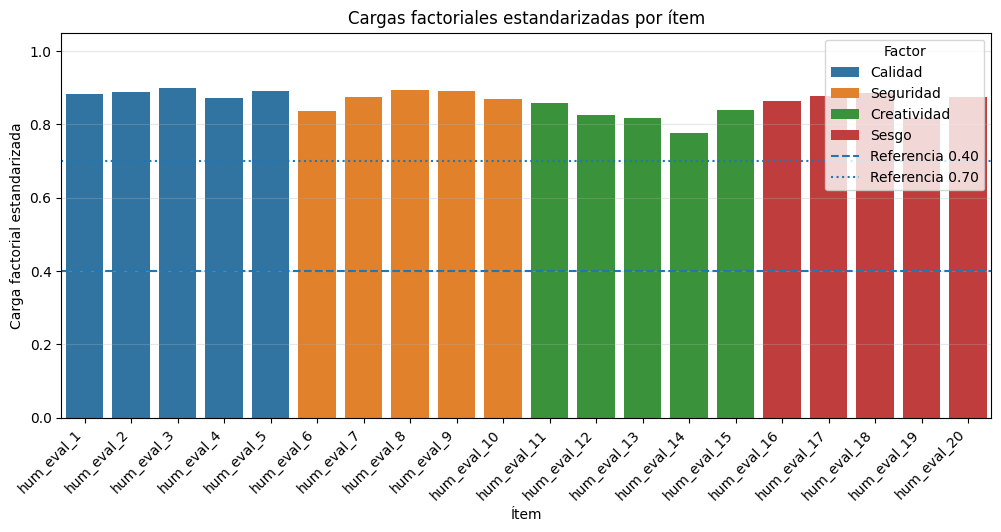

In [13]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=cargas,
    x="item",
    y="carga_estandarizada",
    hue="factor"
)

plt.axhline(0.40, linestyle="--", label="Referencia 0.40")
plt.axhline(0.70, linestyle=":", label="Referencia 0.70")

plt.title("Cargas factoriales estandarizadas por ítem")
plt.xlabel("Ítem")
plt.ylabel("Carga factorial estandarizada")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Factor")
plt.show()

In [14]:
correlaciones_factores = parametros[
    (parametros["op"] == "~~") &
    (parametros["lval"].isin(factores)) &
    (parametros["rval"].isin(factores)) &
    (parametros["lval"] != parametros["rval"])
].copy()

correlaciones_factores = correlaciones_factores.rename(columns={
    "lval": "factor_1",
    "rval": "factor_2",
    columna_estandarizada: "correlacion_estandarizada"
})

display(
    correlaciones_factores[[
        "factor_1",
        "factor_2",
        "correlacion_estandarizada",
        "p-value"
    ]].round(3)
)

,factor_1,factor_2,correlacion_estandarizada,p-value
20,Calidad,Seguridad,0.784,0.0
21,Calidad,Creatividad,-0.247,0.001745
22,Calidad,Sesgo,-0.483,0.0
24,Seguridad,Creatividad,-0.271,0.000723
25,Seguridad,Sesgo,-0.425,0.000001
27,Creatividad,Sesgo,0.462,0.0


In [15]:
# Excluimos la columna identificadora
columna_id = "prompt_id"

variables_analisis = [col for col in df.columns if col != columna_id]

X = df[variables_analisis].copy()
X = X.apply(pd.to_numeric, errors="coerce")

print("Dimensiones de la matriz completa X:", X.shape)

Dimensiones de la matriz completa X: (200, 3000)


In [16]:
n, p = X.shape

rango_maximo_covarianza = min(n - 1, p)

tabla_dimension = pd.DataFrame({
    "cantidad": ["n observaciones", "p variables", "rango máximo de la matriz de covarianza"],
    "valor": [n, p, rango_maximo_covarianza]
})

display(tabla_dimension)

if p > n:
    print(
        f"Como p = {p} y n = {n}, se cumple p >> n. "
        f"La matriz de covarianza tendría dimensión {p} x {p}, "
        f"pero su rango máximo sería {rango_maximo_covarianza}. "
        "Por tanto, la matriz de covarianza es singular y no puede invertirse de forma estable."
    )

,cantidad,valor
0,n observaciones,200
1,p variables,3000
2,rango máximo de la matriz de covarianza,199


Como p = 3000 y n = 200, se cumple p >> n. La matriz de covarianza tendría dimensión 3000 x 3000, pero su rango máximo sería 199. Por tanto, la matriz de covarianza es singular y no puede invertirse de forma estable.


In [17]:
escalador = StandardScaler()

X_std = pd.DataFrame(
    escalador.fit_transform(X),
    columns=variables_analisis,
    index=X.index
)

display(X_std.iloc[:, :10].describe().T[["mean", "std"]].round(3))

,mean,std
hum_eval_1,0.0,1.003
hum_eval_2,0.0,1.003
hum_eval_3,0.0,1.003
hum_eval_4,-0.0,1.003
hum_eval_5,0.0,1.003
hum_eval_6,0.0,1.003
hum_eval_7,-0.0,1.003
hum_eval_8,0.0,1.003
hum_eval_9,0.0,1.003
hum_eval_10,-0.0,1.003


In [18]:
componentes_maximos = min(n - 1, p)

pca = PCA(n_components=componentes_maximos, random_state=42)
pca.fit(X_std)

varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

tabla_varianza = pd.DataFrame({
    "componente": np.arange(1, componentes_maximos + 1),
    "varianza_explicada": varianza_explicada,
    "varianza_acumulada": varianza_acumulada
})

display(tabla_varianza.head(20).round(3))

,componente,varianza_explicada,varianza_acumulada
0,1,0.058,0.058
1,2,0.048,0.106
2,3,0.029,0.135
3,4,0.028,0.163
4,5,0.026,0.188
5,6,0.023,0.212
6,7,0.021,0.233
7,8,0.020,0.253
8,9,0.018,0.271
9,10,0.017,0.288


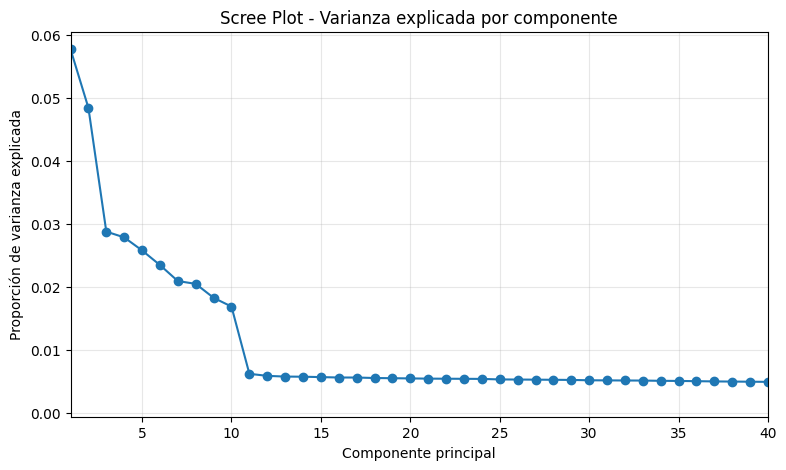

In [19]:
plt.figure(figsize=(9, 5))

plt.plot(
    tabla_varianza["componente"],
    tabla_varianza["varianza_explicada"],
    marker="o"
)

plt.title("Scree Plot - Varianza explicada por componente")
plt.xlabel("Componente principal")
plt.ylabel("Proporción de varianza explicada")
plt.xlim(1, 40)
plt.grid(alpha=0.3)
plt.show()

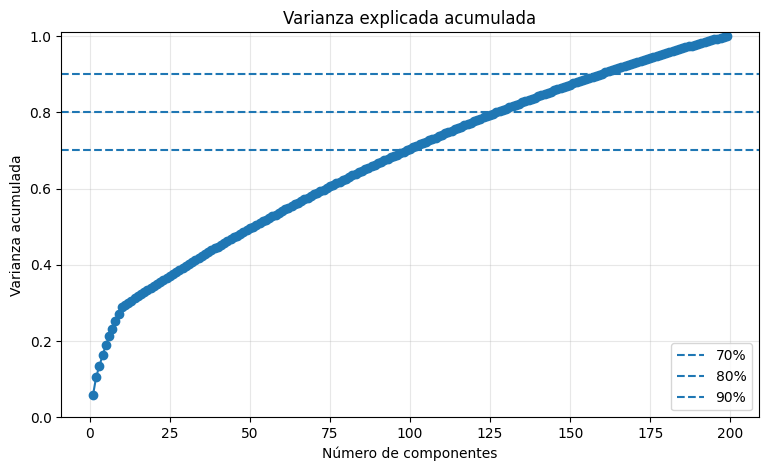

In [20]:
plt.figure(figsize=(9, 5))

plt.plot(
    tabla_varianza["componente"],
    tabla_varianza["varianza_acumulada"],
    marker="o"
)

plt.axhline(0.70, linestyle="--", label="70%")
plt.axhline(0.80, linestyle="--", label="80%")
plt.axhline(0.90, linestyle="--", label="90%")

plt.title("Varianza explicada acumulada")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.ylim(0, 1.01)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [21]:
umbrales = [0.70, 0.80, 0.90]

tabla_umbrales = pd.DataFrame({
    "umbral": umbrales,
    "componentes_necesarios": [
        np.argmax(varianza_acumulada >= umbral) + 1
        for umbral in umbrales
    ]
})

display(tabla_umbrales)

,umbral,componentes_necesarios
0,0.7,99
1,0.8,128
2,0.9,160


In [22]:
def detectar_codo(varianza_explicada, max_componentes=40):
    """
    Detecta el codo del scree plot usando la distancia máxima
    entre la curva y la línea que une el primer y último punto.
    """
    y = varianza_explicada[:max_componentes]
    x = np.arange(1, len(y) + 1)

    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())

    punto_inicial = np.array([x_norm[0], y_norm[0]])
    punto_final = np.array([x_norm[-1], y_norm[-1]])

    puntos = np.column_stack([x_norm, y_norm])

    distancias = np.abs(
        np.cross(
            punto_final - punto_inicial,
            punto_inicial - puntos
        )
    ) / np.linalg.norm(punto_final - punto_inicial)

    return int(x[np.argmax(distancias)])


m_codo = detectar_codo(varianza_explicada, max_componentes=40)

print(f"Número de componentes sugerido por el codo: {m_codo}")
print(f"Varianza acumulada con {m_codo} componentes: {varianza_acumulada[m_codo - 1]:.4f}")

Número de componentes sugerido por el codo: 11
Varianza acumulada con 11 componentes: 0.2944


/tmp/ipykernel_12087/3612865771.py:18: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  np.cross(


El Scree Plot y la detección del codo sugiere un punto de quiebre de 11. Por tanto, se retienen 11 componentes/factores que explican aproximadamente el 29.44% de la varianza acumulada.

Aunque este porcentaje no es alto es esperable en un contexto de alta dimensionalidad con 3000 variables heterogéneas.

Además, conservar umbrales clásicos de 70%, 80% o 90% exigiría retener muchos componentes, lo cual reduciría la parsimonia del análisis y podría afectar la estabilidad del clustering posterior.

### Puntuaciones PCA no rotadas

In [23]:
# Ajusta este valor después de revisar el Scree Plot y la tabla de varianza acumulada.
# En una primera corrida, 10 suele ser una opción razonable si el codo aparece cerca de ese punto.

m_retener = m_codo

print(f"Número de componentes retenidos: m = {m_retener}")
print(f"Varianza acumulada retenida: {varianza_acumulada[m_retener - 1]:.4f}")

Número de componentes retenidos: m = 11
Varianza acumulada retenida: 0.2944


In [24]:
puntuaciones_pca = pca.transform(X_std)[:, :m_retener]

columnas_componentes = [f"PC{i}" for i in range(1, m_retener + 1)]

df_puntuaciones_pca = pd.DataFrame(
    puntuaciones_pca,
    columns=columnas_componentes,
    index=df.index
)

df_puntuaciones_pca.insert(0, columna_id, df[columna_id])

display(df_puntuaciones_pca.head())

,prompt_id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,1,-3.762642,3.818123,-3.155322,9.929193,-9.796495,-10.005448,-3.786385,15.099277,0.424357,-0.093480,5.565281
1,2,-21.611601,3.091203,-4.868995,19.179669,-3.266265,-5.070660,-18.077943,-4.363461,-2.369366,4.767542,-1.863564
2,3,9.646840,-6.320652,-2.674794,0.121550,8.580772,-8.937765,-1.373618,1.033195,3.805386,16.582735,2.655355
3,4,-17.527348,-0.486739,-1.715500,9.992099,11.155138,-7.939487,0.624458,-13.779531,6.829820,2.392221,0.559925
4,5,-36.911566,14.203972,13.403279,-1.337587,-4.905458,2.893842,11.254652,9.573722,-8.986628,-7.244087,-1.784802


### Rotación Varimax

In [25]:
# Cargas de los primeros m componentes
cargas_pca = pca.components_[:m_retener].T * np.sqrt(
    pca.explained_variance_[:m_retener]
)

rotador = Rotator(method="varimax")

cargas_rotadas = rotador.fit_transform(cargas_pca)

# Como Varimax es una rotación ortogonal, se rotan también las puntuaciones
puntuaciones_rotadas = puntuaciones_pca @ rotador.rotation_

columnas_factores = [f"F{i}" for i in range(1, m_retener + 1)]

df_puntuaciones_factoriales = pd.DataFrame(
    puntuaciones_rotadas,
    columns=columnas_factores,
    index=df.index
)

df_puntuaciones_factoriales.insert(0, columna_id, df[columna_id])

display(df_puntuaciones_factoriales.head())

,prompt_id,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11
0,1,-2.833305,8.777095,3.364379,9.002714,-15.081488,-2.194282,-9.745821,6.284805,-5.585405,-0.320493,5.600757
1,2,-22.044537,14.350405,5.596424,0.770162,0.840039,0.247824,-19.951320,-9.445900,-7.921758,2.452062,-1.268359
2,3,3.554696,-11.933227,-2.333703,12.360768,4.738150,-4.112474,-6.881729,0.662603,2.662115,13.456070,2.140812
3,4,-16.613237,4.402221,3.050372,3.996237,19.146098,-8.887487,-7.320326,-2.115438,-0.708212,-3.694280,1.491517
4,5,-17.669655,28.771107,11.150456,-3.146774,4.832730,12.760809,12.544688,18.895312,-9.155055,-8.150319,-2.787496


In [28]:
df_cargas_rotadas = pd.DataFrame(
    cargas_rotadas,
    index=variables_analisis,
    columns=columnas_factores
)

top_variables = []

for factor in columnas_factores:
    top = (
        df_cargas_rotadas[factor]
        .abs()
        .sort_values(ascending=False)
        .head(5)
    )
    
    for variable, carga_abs in top.items():
        top_variables.append({
            "factor": factor,
            "variable": variable,
            "carga_rotada": df_cargas_rotadas.loc[variable, factor],
            "carga_abs": carga_abs
        })

tabla_top_variables = pd.DataFrame(top_variables)

display(tabla_top_variables.round(3))

,factor,variable,carga_rotada,carga_abs
0,F1,int_metric_1752,-0.693,0.693
1,F1,int_metric_1506,-0.682,0.682
2,F1,int_metric_276,0.676,0.676
3,F1,int_metric_1337,0.665,0.665
4,F1,int_metric_1491,-0.649,0.649
5,F2,int_metric_2068,-0.673,0.673
6,F2,int_metric_2028,-0.649,0.649
7,F2,int_metric_842,-0.624,0.624
8,F2,int_metric_441,0.607,0.607
9,F2,int_metric_2134,0.600,0.600


Los factores F1 a F10 representan dimensiones técnicas internas del comportamiento del modelo. 

Dado que las variables `int_metric_*` no tienen una importancia relacionada con el factor humano, estos factores se usarán principalmente como coordenadas estructurales para clustering.

El factor F11 captura principalmente una dimensión asociada con la evaluación humana de Seguridad.

Esto es consistente con el CFA previo, donde los ítems `hum_eval_6` a `hum_eval_10` fueron tratados como indicadores del constructo Seguridad.

In [27]:
Z_factorial = df_puntuaciones_factoriales[columnas_factores].copy()

print("Dimensiones de la matriz original:", X.shape)
print("Dimensiones de la matriz reducida:", Z_factorial.shape)

display(Z_factorial.head())

Dimensiones de la matriz original: (200, 3000)
Dimensiones de la matriz reducida: (200, 11)


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11
0,-2.833305,8.777095,3.364379,9.002714,-15.081488,-2.194282,-9.745821,6.284805,-5.585405,-0.320493,5.600757
1,-22.044537,14.350405,5.596424,0.770162,0.840039,0.247824,-19.951320,-9.445900,-7.921758,2.452062,-1.268359
2,3.554696,-11.933227,-2.333703,12.360768,4.738150,-4.112474,-6.881729,0.662603,2.662115,13.456070,2.140812
3,-16.613237,4.402221,3.050372,3.996237,19.146098,-8.887487,-7.320326,-2.115438,-0.708212,-3.694280,1.491517
4,-17.669655,28.771107,11.150456,-3.146774,4.832730,12.760809,12.544688,18.895312,-9.155055,-8.150319,-2.787496


## Conclusión parcial

La matriz completa del estudio presenta una condición clara de alta dimensionalidad, con \(p = 3000\) variables y solo \(n = 200\) observaciones. En este escenario, la matriz de covarianza es singular o inestable, por lo que no resulta conveniente aplicar directamente métodos multivariados clásicos ni algoritmos de clustering sobre el espacio original.

El Análisis de Componentes Principales permitió proyectar los datos a un espacio reducido. El Scree Plot sugirió un punto de codo alrededor de \(m = 11\) componentes, los cuales explican aproximadamente el 29.44% de la varianza acumulada. Aunque esta proporción no es alta, es razonable en un conjunto de datos de alta dimensionalidad y con variables heterogéneas. Además, conservar el 70%, 80% o 90% de la varianza requeriría 99, 128 y 160 componentes respectivamente, lo que reduciría la parsimonia del análisis y podría afectar la estabilidad del clustering posterior.

Después de aplicar rotación Varimax, se observó que los factores F1 a F10 están dominados principalmente por métricas internas del modelo, por lo que se interpretan como dimensiones técnicas latentes del comportamiento de NLA-7B. En cambio, el factor F11 presenta cargas altas en `hum_eval_6`, `hum_eval_7`, `hum_eval_8`, `hum_eval_9` y `hum_eval_10`, lo que permite asociarlo con la dimensión humana de Seguridad definida en la sección anterior.

En consecuencia, se retienen 11 factores rotados como nuevo espacio de características. Esta matriz reducida conserva las dimensiones más estructuradas del conjunto de datos y será utilizada como entrada para la etapa de identificación de tipologías mediante clustering.

# Identificación de Tipologías

En esta sección se identifican tipologías de prompts a partir de la matriz reducida de puntuaciones factoriales.

En lugar de aplicar clustering directamente sobre las 3000 variables originales, se trabaja sobre el espacio factorial de baja dimensión obtenido en la sección anterior:

\[
X_{200 \times 3000} \rightarrow Z_{200 \times 11}
\]

Este enfoque es más estable porque reduce ruido, evita problemas asociados a la alta dimensionalidad y permite que los algoritmos de clustering trabajen sobre una representación más compacta de cada prompt.

Se aplican dos métodos:

1. K-Means, como algoritmo de particionamiento.
2. Clustering jerárquico aglomerativo con método de Ward.

El número de clústeres se evalúa mediante el coeficiente de silueta y el análisis del dendrograma.

In [29]:
escalador_cluster = StandardScaler()

Z_cluster = pd.DataFrame(
    escalador_cluster.fit_transform(Z_factorial),
    columns=Z_factorial.columns,
    index=Z_factorial.index
)

display(Z_cluster.describe().T[["mean", "std"]].round(3))

,mean,std
F1,0.0,1.003
F2,0.0,1.003
F3,0.0,1.003
F4,-0.0,1.003
F5,-0.0,1.003
F6,0.0,1.003
F7,0.0,1.003
F8,-0.0,1.003
F9,0.0,1.003
F10,0.0,1.003
